In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


df = pd.read_csv("refined_economic_dataset.csv")
print(f"\n  Dataset loaded successfully!")
print(f"    Rows : {df.shape[0]}  |  Columns : {df.shape[1]}")
# print(f"\nFirst 5 rows :\n{df.head()}")


print("\n  Dataset Info :")
print(f"    Countries : {sorted(df['country_name'].unique())}")
print(f"    Year Range: {df['year'].min()} → {df['year'].max()}")
print(f"    Missing Values :\n{df.isnull().sum()}")
print(f"\n  Statistical Summary :\n{df.describe().round(2)}")



  Dataset loaded successfully!
    Rows : 345  |  Columns : 10

  Dataset Info :
    Countries : ['Bangladesh', 'China', 'India', 'Indonesia', 'Kazakhstan', 'Korea, Rep.', 'Malaysia', 'Philippines', 'Saudi Arabia', 'Singapore', 'Sri Lanka', 'Thailand', 'Turkiye', 'United Arab Emirates', 'Viet Nam']
    Year Range: 2001 → 2023
    Missing Values :
country_name             0
year                     0
health_expense           0
total_gov_expense        0
education_expense        0
capital_formation_exp    0
military_expense         0
r&d_expense              0
total_gdp                0
log_gdp                  0
dtype: int64

  Statistical Summary :
          year  health_expense  total_gov_expense  education_expense  \
count   345.00          345.00             345.00             345.00   
mean   2012.00            3.92              16.95               3.60   
std       6.64            1.14               6.38               1.18   
min    2001.00            1.77               3.70     

In [71]:
TARGET_COLS = [
    "health_expense",
    "total_gov_expense",
    "education_expense",
    "capital_formation_exp",
    "military_expense",
    "r&d_expense"
]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]


In [72]:
le = LabelEncoder()
df["country_encoded"] = le.fit_transform(df["country_name"])


country_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\n  Country Encoding Map :")
for k, v in country_mapping.items():
    print(f"    {v:2d} → {k}")
# df['country_encoded'].unique()

df["log_gdp"] = np.log10(df["total_gdp"])
FEATURE_COLS = ["country_encoded", "year",  "log_gdp"]

X = df[FEATURE_COLS]   # Input features
Y = df[TARGET_COLS]    # Output targets (6 sectors)

print(f"\n  Feature matrix X shape : {X.shape}")
print(f"  Target matrix  Y shape : {Y.shape}")
print(f"\n   Features used : {FEATURE_COLS}")
print(f"   Targets       : {TARGET_COLS}")

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42
)

print(f"\n   Training samples : {X_train.shape[0]}")
print(f"   Testing  samples : {X_test.shape[0]}")



  Country Encoding Map :
     0 → Bangladesh
     1 → China
     2 → India
     3 → Indonesia
     4 → Kazakhstan
     5 → Korea, Rep.
     6 → Malaysia
     7 → Philippines
     8 → Saudi Arabia
     9 → Singapore
    10 → Sri Lanka
    11 → Thailand
    12 → Turkiye
    13 → United Arab Emirates
    14 → Viet Nam

  Feature matrix X shape : (345, 3)
  Target matrix  Y shape : (345, 6)

   Features used : ['country_encoded', 'year', 'log_gdp']
   Targets       : ['health_expense', 'total_gov_expense', 'education_expense', 'capital_formation_exp', 'military_expense', 'r&d_expense']

   Training samples : 276
   Testing  samples : 69


In [73]:
base_tree = DecisionTreeRegressor(
    max_depth=6,            # Controls complexity of the tree
    min_samples_split=5,    # Min samples required to split a node
    min_samples_leaf=3,     # Min samples required at a leaf node
    random_state=42         # Reproducibility
)
model = MultiOutputRegressor(base_tree)
model.fit(X_train, Y_train)

Y_pred_test  = model.predict(X_test)
Y_pred_train = model.predict(X_train)

In [74]:
Y_pred_test.shape

(69, 6)

In [75]:
results = []
for i, col in enumerate(TARGET_COLS):
    r2_train = r2_score(Y_train.iloc[:, i], Y_pred_train[:, i])
    r2_test  = r2_score(Y_test.iloc[:, i],  Y_pred_test[:, i])
    mae      = mean_absolute_error(Y_test.iloc[:, i], Y_pred_test[:, i])
    rmse     = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred_test[:, i]))

    results.append({
        "Sector": col,
        "R² Train": round(r2_train, 4),
        "R² Test":  round(r2_test, 4),
        "MAE":      round(mae, 4),
        "RMSE":     round(rmse, 4)
    })


results_df = pd.DataFrame(results)
print("\n  Evaluation Metrics per Sector :\n")
print(results_df.to_string(index=False))


  Evaluation Metrics per Sector :

               Sector  R² Train  R² Test    MAE   RMSE
       health_expense    0.8849   0.7925 0.3437 0.5047
    total_gov_expense    0.8889   0.8245 1.4906 2.2234
    education_expense    0.8360   0.5952 0.4081 0.6365
capital_formation_exp    0.8789   0.7835 2.1759 2.8608
     military_expense    0.9770   0.8717 0.3930 0.7726
          r&d_expense    0.9094   0.8604 0.2274 0.3429


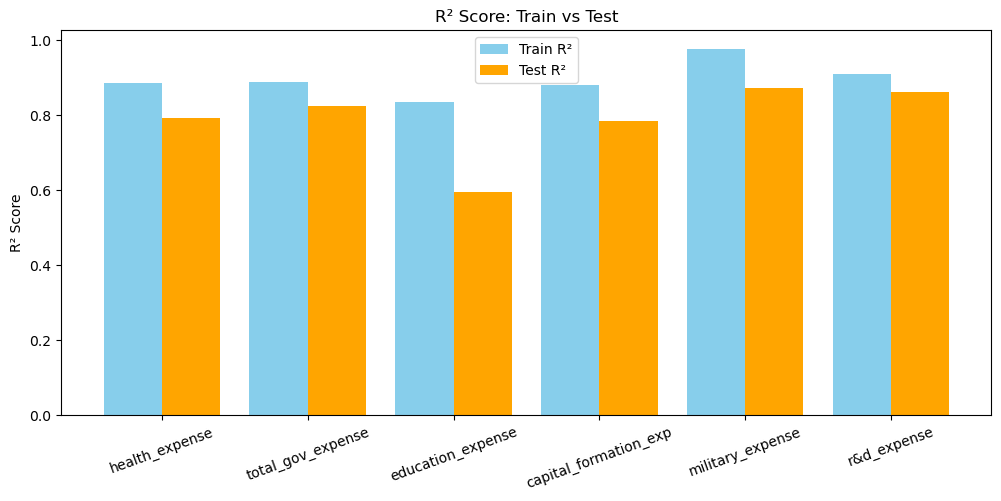

In [76]:

plt.figure(figsize=(12, 5))
x = np.arange(len(TARGET_COLS)) 


plt.bar(x - 0.2, results_df["R² Train"], width=0.4, label="Train R²", color="skyblue")
plt.bar(x + 0.2, results_df["R² Test"], width=0.4, label="Test R²", color="orange")


plt.xticks(x, TARGET_COLS, rotation=20) 
plt.ylabel("R² Score")
plt.title("R² Score: Train vs Test")
plt.legend() 



plt.show()

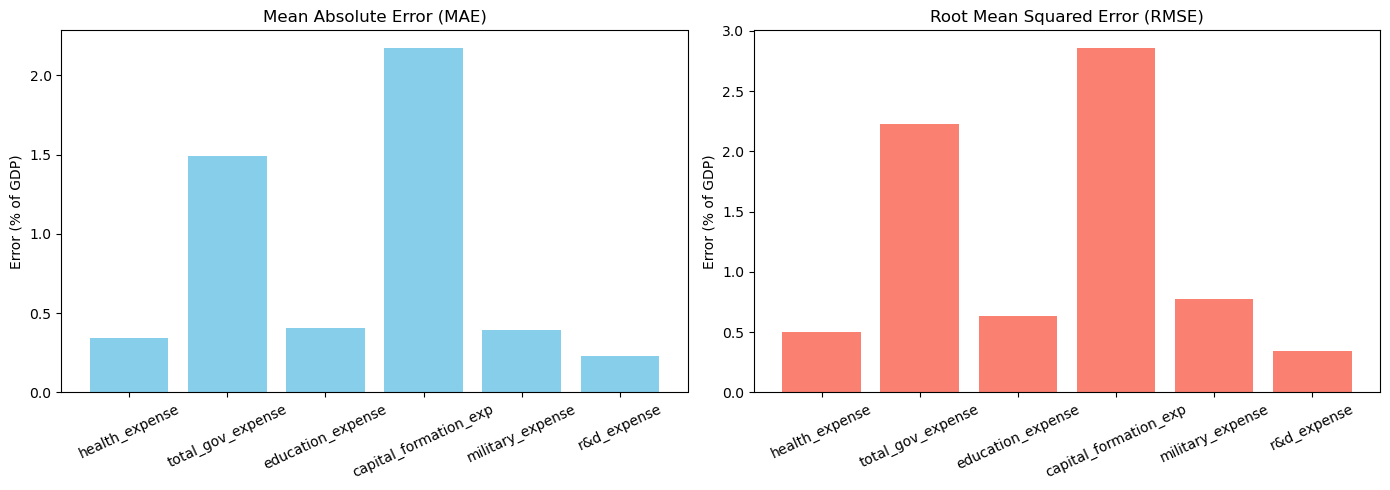

In [77]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(TARGET_COLS, results_df["MAE"], color='skyblue')
axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("Error (% of GDP)")
axes[0].tick_params(axis='x', rotation=25) 


axes[1].bar(TARGET_COLS, results_df["RMSE"], color='salmon')
axes[1].set_title("Root Mean Squared Error (RMSE)")
axes[1].set_ylabel("Error (% of GDP)")
axes[1].tick_params(axis='x', rotation=25)


plt.tight_layout()
plt.show()

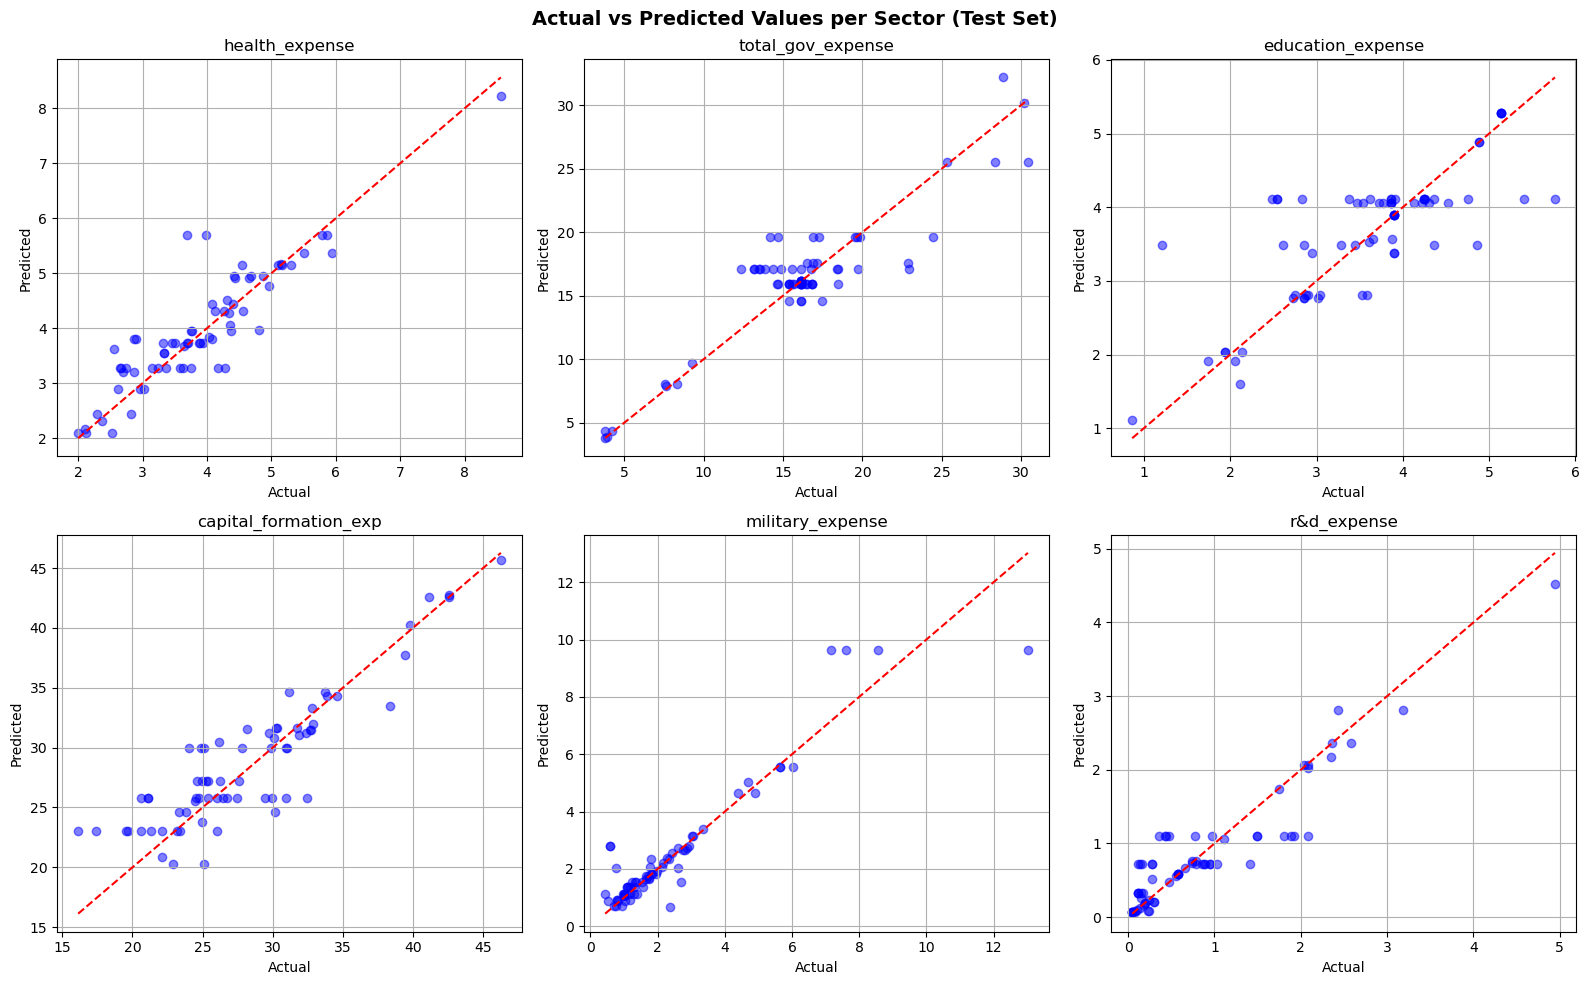

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Actual vs Predicted Values per Sector (Test Set)",fontsize=14, fontweight="bold")

for i, col in enumerate(TARGET_COLS):
    
    plt.subplot(2, 3, i + 1)
    
    
    actual = Y_test.iloc[:, i]
    predicted = Y_pred_test[:, i]
    plt.scatter(actual, predicted, color='blue', alpha=0.5)
    
    
    plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--')
    
    
    plt.title(col)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True)


plt.tight_layout()
plt.show()

In [80]:
VALID_COUNTRIES = sorted(df["country_name"].unique())
def predict_expenditure(country_name: str,
                         year: int,
                         total_gdp: float) -> pd.DataFrame:
    """
    Predict sector expenditures for a given country, year, and GDP.

    Parameters
    ----------
    country_name : str   (e.g. "India")
    year         : int   (e.g. 2022)
    total_gdp    : float (in USD, e.g. 3_500_000_000_000)

    Returns
    -------
    A DataFrame showing predicted % of GDP for each sector.
    """

    # ── Validate country name ──────────────────
    if country_name not in VALID_COUNTRIES:
        # Find closest match for friendly error message
        suggestions = [c for c in VALID_COUNTRIES
                       if country_name.lower() in c.lower()]
        if suggestions:
            raise ValueError(
                f"  '{country_name}' not found.\n"
                f"   Did you mean: {suggestions}?\n"
                f"   Available: {VALID_COUNTRIES}"
            )
        else:
            raise ValueError(
                f"  '{country_name}' not in dataset.\n"
                f"   Available countries: {VALID_COUNTRIES}"
            )

    
    if not (2000 <= year <= 2100):
        raise ValueError(f"  Year {year} seems unrealistic. Use a 4-digit year.")

    
    if total_gdp <= 0:
        raise ValueError(" GDP must be a positive number.")

  
    country_encoded = country_mapping[country_name]
    log_gdp         = np.log10(total_gdp)

    # Create a single-row DataFrame matching training structure
    input_df = pd.DataFrame({
        "country_encoded": [country_encoded],
        "year":            [year],
        "total_gdp":       [total_gdp],
        "log_gdp":         [log_gdp]
    })

    
    pred_array = model.predict(input_df)[0]   # shape: (6,)

    
    output = pd.DataFrame({
        "Sector":              [c.replace("_", " ").title() for c in TARGET_COLS],
        "Predicted % of GDP":  np.round(pred_array, 4),
        "Estimated USD":       np.round(pred_array / 100 * total_gdp, 2)
    })

    return output

    

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def predict_and_show(country, year, gdp):
    
   
    if country not in VALID_COUNTRIES:
        print(f"'{country}' doesn't exist.\n")
        return 
    
    
    actual_exists = False
    if year <= 2023:
       
        past_data = df[(df['country_name'] == country) & (df['year'] == year)]
        if not past_data.empty:
            actual_exists = True
            
            actual_percentages = past_data[TARGET_COLS].values[0]
    elif year>2023:
        past_data = df[(df['country_name'] == country) & (df['year'] ==df['year'].max() )]
        if not past_data.empty:
            
            
            last_year_percentages = past_data[TARGET_COLS].values[0]

            
    
    country_code = country_mapping[country]
    log_gdp = np.log10(gdp)
    
    input_df = pd.DataFrame({
        "country_encoded": [country_code],
        "year": [year],
        "log_gdp": [log_gdp]
       
    })
    
   
    pred_percentages = model.predict(input_df)[0]
    billion_usd = (pred_percentages / 100 * gdp) / 1_000_000_000
    
    
    if actual_exists:
        
        results = pd.DataFrame({
            "Sector": TARGET_COLS,
            "Actual (%)": np.round(actual_percentages, 2),
            "Predicted (%)": np.round(pred_percentages, 2),
            "Predicted (Billion USD)": np.round(billion_usd, 2)
        })
        
    else:
        results = pd.DataFrame({
            "Sector": TARGET_COLS,
            "Nearest (%)" :  np.round(last_year_percentages,2),
            "Predicted (%)": np.round(pred_percentages, 2),
            "Predicted (Billion USD)": np.round(billion_usd, 2)
        })
    
    print(f"\n Result: {country} ({year})")
    print("-" * 50)
    print(results.to_string(index=False))
    
   
    plt.figure(figsize=(10, 5))
    
    if actual_exists:
       
        x = np.arange(len(TARGET_COLS)) 
        width = 0.35 
        
        
        plt.bar(x - width/2, actual_percentages, width=width, label='Actual Data', color='salmon')
        
        plt.bar(x + width/2, results["Predicted (%)"], width=width, label='Predicted Data', color='skyblue')
        
        
        plt.xticks(x, results["Sector"], rotation=15)
        plt.legend()
        plt.title(f"Actual vs Predicted Expenditure for {country} ({year})")
        
    else:
        x = np.arange(len(TARGET_COLS)) # ০, ১, ২, ৩, ৪, ৫
        width = 0.35 
        
        
        plt.bar(x - width/2, last_year_percentages, width=width, label='Last Year data', color='salmon')
        
        plt.bar(x + width/2, results["Predicted (%)"], width=width, label='Predicted Data', color='skyblue')
        
        
        plt.xticks(x, results["Sector"], rotation=15)
        plt.legend()
        plt.title(f"Last Year  vs Predicted Expenditure for {country} ({year})")
        
    plt.ylabel("% of GDP")
    plt.grid(axis='y', alpha=0.3) 
    plt.tight_layout()
    plt.show()


print("\nWelcome to Budget Predictor Model!")
print("To exit this program, enter  'quit' \n")

while True:
    print("=" * 50)
    print(df['country_name'].unique().tolist())
    user_country = input("Enter Country Name : ").strip()
    
    if user_country.lower() == "quit":
        print("Exit")
        break
        
    try:
        user_year = int(input("Enter Year : "))
        if user_year<2024 and user_year>2000:
            past_data1 = df[(df['country_name'] == user_country) & (df['year'] == user_year)].reset_index(drop=True)
            # print(past_data1)
            user_gdp = float(input(f"Enter Total GDP (USD ): {past_data1['total_gdp'].values[0]}")) 
        
        else:
            
            max_gdp = df[(df['country_name'] == user_country)]['total_gdp'].max()
            min_gdp = df[(df['country_name'] == user_country)]['total_gdp'].min()
            user_gdp = float(input(f"Enter Total GDP (USD ): {min_gdp} to {max_gdp} "))
        predict_and_show(user_country, user_year, user_gdp)
        
    except ValueError as e:
        print(f"⚠️ Error: {e})")


Welcome to Budget Predictor Model!
To exit this program, enter  'quit' 

['Bangladesh', 'China', 'India', 'Indonesia', 'Kazakhstan', 'Korea, Rep.', 'Malaysia', 'Philippines', 'Saudi Arabia', 'Singapore', 'Sri Lanka', 'Thailand', 'Turkiye', 'United Arab Emirates', 'Viet Nam']


In [ ]:
# df[(df['country_name'].isin( ['Bangladesh','China', 'India', 'Indonesia', 'Kazakhstan'])) & (df['year'].isin([2020,2010,2005,2018]))]